ESERCIZIO

Modifica il codice fornito nella lezione per confrontare due metodi di condizionamento.
1) eseguire il traing usando one-hot encoding tra 5 epoche
2) eseguire il traing usante embedding layer di dimensione 50 per 5 epoche. 
Quale dei due modelli produce immagini di Fashion MINST più nitide e corenti?

Suggerimento: osserva la griglia 10x10 finale e nota se ci sono classi 'fuse' tra loro


--- INIZIO EXPERIMENT: ONEHOT ---


Modo onehot - Epoca 5: 100%|██████████| 469/469 [00:29<00:00, 15.78it/s]



--- INIZIO EXPERIMENT: EMBEDDING ---


Modo embedding - Epoca 5: 100%|██████████| 469/469 [00:31<00:00, 14.70it/s]


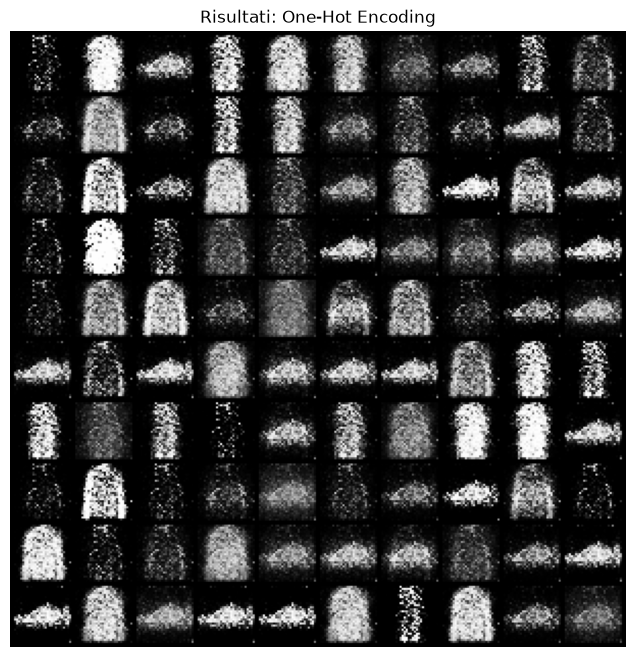

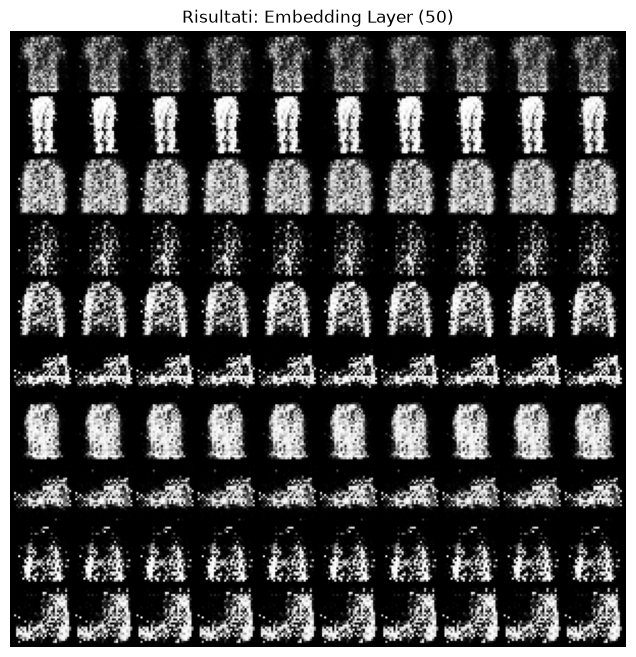

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
n_classes = 10
epochs = 5  # Come richiesto
lr = 0.0002

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

# --- MODELLI FLESSIBILI ---

class Generator(nn.Module):
    def __init__(self, mode="embedding", embed_dim=50):
        super().__init__()
        self.mode = mode
        self.cond_dim = n_classes if mode == "onehot" else embed_dim
        
        if mode == "embedding":
            self.label_embed = nn.Embedding(n_classes, embed_dim)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + self.cond_dim, 256), 
            nn.ReLU(True),
            nn.Linear(256, 512), 
            nn.ReLU(True),
            nn.Linear(512, 1024), 
            nn.ReLU(True),
            nn.Linear(1024, 784), 
            nn.Tanh() 
        )

    def forward(self, noise, labels):
        if self.mode == "onehot":
            # Converte l'indice in un vettore di zeri e un singolo uno
            cond = F.one_hot(labels, num_classes=n_classes).float()
        else:
            cond = self.label_embed(labels)
            
        x = torch.cat([noise, cond], dim=1)
        return self.model(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, mode="embedding", embed_dim=50):
        super().__init__()
        self.mode = mode
        self.cond_dim = n_classes if mode == "onehot" else embed_dim
        
        if mode == "embedding":
            self.label_embed = nn.Embedding(n_classes, embed_dim)
            
        self.model = nn.Sequential(
            nn.Linear(784 + self.cond_dim, 512), 
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1), 
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        if self.mode == "onehot":
            cond = F.one_hot(labels, num_classes=n_classes).float()
        else:
            cond = self.label_embed(labels)
            
        x = torch.cat([img.view(-1, 784), cond], dim=1)
        return self.model(x)

# --- FUNZIONE DI TRAINING ---

def run_experiment(mode, embed_dim=50):
    print(f"\n--- INIZIO EXPERIMENT: {mode.upper()} ---")
    netG = Generator(mode, embed_dim).to(device)
    netD = Discriminator(mode, embed_dim).to(device)
    
    optG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
    optD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Modo {mode} - Epoca {epoch+1}")
        for real_imgs, labels in pbar:
            b_size = real_imgs.size(0)
            real_imgs, labels = real_imgs.to(device), labels.to(device)

            # Train Discriminator
            netD.zero_grad()
            out_real = netD(real_imgs, labels)
            loss_real = criterion(out_real, torch.ones(b_size, 1, device=device))
            
            noise = torch.randn(b_size, latent_dim, device=device)
            fake_imgs = netG(noise, labels)
            out_fake = netD(fake_imgs.detach(), labels)
            loss_fake = criterion(out_fake, torch.zeros(b_size, 1, device=device))
            (loss_real + loss_fake).backward()
            optD.step()

            # Train Generator
            netG.zero_grad()
            out_g = netD(fake_imgs, labels)
            loss_g = criterion(out_g, torch.ones(b_size, 1, device=device))
            loss_g.backward()
            optG.step()
    
    return netG

# --- ESECUZIONE ---

model_onehot = run_experiment("onehot")
model_embed = run_experiment("embedding", embed_dim=50)

def show_results(netG, title):
    netG.eval()
    test_labels = torch.arange(10).repeat_interleave(10).to(device)
    test_noise = torch.randn(100, latent_dim, device=device)
    with torch.no_grad():
        samples = netG(test_noise, test_labels).cpu()
    grid = utils.make_grid(samples, nrow=10, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

show_results(model_onehot, "Risultati: One-Hot Encoding")
show_results(model_embed, "Risultati: Embedding Layer (50)")